In [16]:
import pywt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose


In [17]:
df = pd.read_csv("Naxod.csv")
df["ds"] = pd.to_datetime(df["ds"])
df = df.set_index('ds')


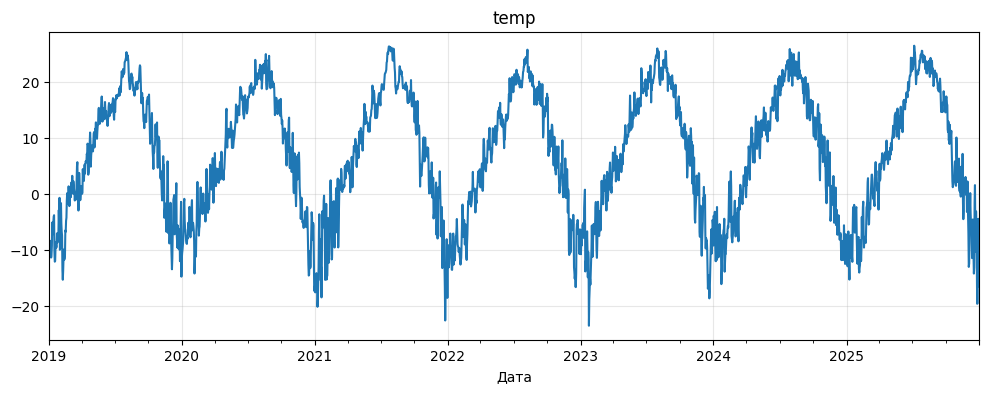

In [18]:

df["temp"].plot(figsize=(12, 4), title="temp")
plt.xlabel('Дата')
plt.grid(True, alpha=0.3)
plt.show()

Смотрим график температуры от времени визуально. Видим выраженную годичную сезонность.

In [19]:
result = adfuller(df["temp"], autolag='AIC')

print('ADF Statistic: {:.4f}'.format(result[0]))
print('p-value: {:.4f}'.format(result[1]))
print('Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value:.4f}')
if result[1] <= 0.05:
    print('=> Ряд стационарен (отвергаем H0)')
else:
    print('=> Ряд НЕ стационарен (не отвергаем H0)')

ADF Statistic: -2.8357
p-value: 0.0533
Critical Values:
   1%: -3.4329
   5%: -2.8627
   10%: -2.5674
=> Ряд НЕ стационарен (не отвергаем H0)


Проверяем ряд на стационарность с посощью теста Дике-Фулера. Видим сто ряд не стациионарен, что нормально с учетом того, что график показал сезонность. Этот на ниших моделях ни как не повлияет, тк они спокойно работают и сос стационарными и не стационарными рядами

In [20]:
stat, p_value, lags, critical_values = kpss(df["temp"], regression='c', nlags='auto')

print(f'KPSS Statistic: {stat:.4f}')
print(f'p-value: {p_value:.4f}')
print('Critical Values:')
for key, value in critical_values.items():
    print(f'   {key}: {value:.4f}')
if p_value <= 0.05:
    print('=> Ряд НЕ стационарен (отвергаем H0)')
else:
    print('=> Ряд стационарен (нет оснований отвергнуть H0)')

KPSS Statistic: 0.0607
p-value: 0.1000
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
=> Ряд стационарен (нет оснований отвергнуть H0)


C:\Users\Viktoria\AppData\Local\Temp\ipykernel_14028\2901309438.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, critical_values = kpss(df["temp"], regression='c', nlags='auto')


Мы провели еще одну проверку на стационарность, которая показала, что ряд стационарен. Это странно, но в нашем случае не критично, тк на не обязательно знать стационарен ли ряд

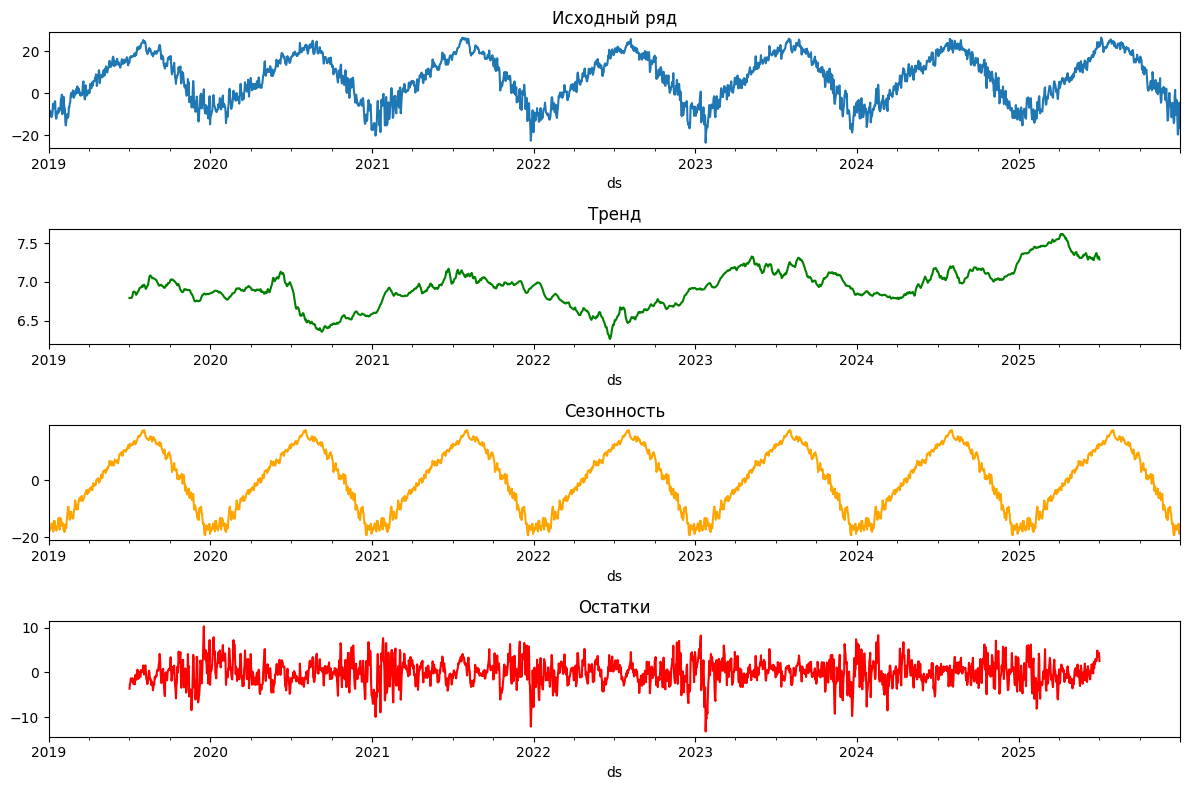

In [21]:
decomposition = seasonal_decompose(df['temp'], model='additive', period=365)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
decomposition.observed.plot(ax=ax1, title='Исходный ряд')
decomposition.trend.plot(ax=ax2, title='Тренд', color='green')
decomposition.seasonal.plot(ax=ax3, title='Сезонность', color='orange')
decomposition.resid.plot(ax=ax4, title='Остатки', color='red')
plt.tight_layout()
plt.show()

Сделаем декомпозицию ряда, чтобы посмотреть тренд, сезонность, остаток. На графиках можно увидеть, сто тренда в нашем графике нет, также присутствует сеззоность, и хаотичный остаток

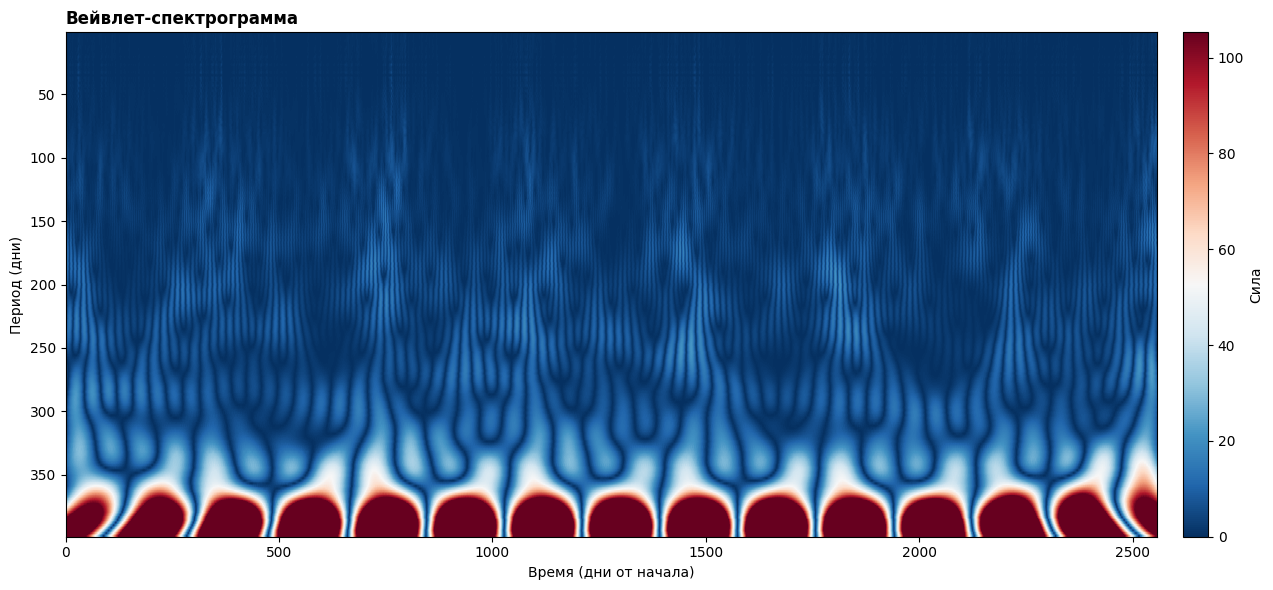

In [22]:
data = df["temp"]
t = np.arange(len(data))

scales = np.geomspace(1, 400, num=200)
coefficients, frequencies = pywt.cwt(data, scales, 'morl', sampling_period=1)

mask = frequencies > 0
periods = 1 / frequencies[mask]
coeff_abs = np.abs(coefficients[mask, :])

period_mask = (periods >= 1) & (periods <= 400)
periods_plot = periods[period_mask]
coeff_plot = coeff_abs[period_mask, :]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(coeff_plot,
               extent=[t.min(), t.max(), periods_plot.max(), periods_plot.min()],
               aspect='auto', cmap='RdBu_r',
               vmin=0, vmax=np.percentile(coeff_plot, 95))
ax.set_title('Вейвлет-спектрограмма', fontweight='bold', loc='left')
ax.set_ylabel('Период (дни)')
ax.set_xlabel('Время (дни от начала)')
plt.colorbar(im, ax=ax, label='Сила', orientation='vertical', pad=0.02)
plt.tight_layout()
plt.show()

Теперь посмотрим спектрограмму, на которорой также можно увидеть четко выраженую годичную сезонность. Теперь можем перейти к обучениям моделей

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import learning_curve, TimeSeriesSplit

In [24]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def directional_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    delta_true = y_true[1:] - y_true[:-1]
    delta_pred = y_pred[1:] - y_true[:-1]  
    correct = np.sign(delta_true) == np.sign(delta_pred)
    return np.mean(correct)

def directional_r2(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    delta_true = y_true[1:] - y_true[:-1]
    delta_pred = y_pred[1:] - y_true[:-1]   
    return r2_score(delta_true, delta_pred)

def calculate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mae = mean_absolute_error(y_true, y_pred)
    
    non_zero = y_true != 0
    mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100
    
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
    
    delta_true = y_true[1:] - y_true[:-1]
    delta_pred = y_pred[1:] - y_true[:-1] 
    dir_acc = np.mean(np.sign(delta_true) == np.sign(delta_pred))
    
    r2 = r2_score(y_true, y_pred)
    
    r2_dir = r2_score(delta_true, delta_pred)
    
    return {
        'MAE': mae,
        'MAPE': mape,
        'WAPE': wape,
        'Directional_Accuracy': dir_acc,
        'Directional_R2': r2_dir
    }

def plot_learning_curve_ts(model, X, y, m=1, cv_splits=4, train_sizes=np.linspace(0.1, 1.0, 8)):
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X, y, cv=tscv, scoring='neg_mean_absolute_error',
        train_sizes=train_sizes, n_jobs=-1
    )
    
    train_mae = -np.mean(train_scores, axis=1)
    val_mae = -np.mean(val_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_abs, train_mae, 'o-', label='Train MAE', color='blue')
    plt.fill_between(train_sizes_abs, train_mae - train_std, train_mae + train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes_abs, val_mae, 'o-', label='Validation MAE', color='red')
    plt.fill_between(train_sizes_abs, val_mae - val_std, val_mae + val_std, alpha=0.1, color='red')
    
    plt.xlabel('Размер обучающей выборки')
    plt.ylabel('MAE')
    plt.title('Обучающая кривая (TimeSeries CV)')
    plt.legend()
    plt.grid(True)
    if m == 0:
        plt.ylim(0, 21)
    plt.show()
    

Здесь представлены функции подсчета ошибок. А также функция для построения графика обучения

In [25]:
def objective_direct_tree(trial,X_train, y_train):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30),
        'criterion': trial.suggest_categorical('criterion', 
                                               ['squared_error', 'friedman_mse', 'absolute_error']),
        'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.2),
    }
    
    model = DecisionTreeRegressor(**params, random_state=42)
    
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)
        scores.append(mae)
    
    return np.mean(scores)

def objective_direct_gb(trial,X_train, y_train):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = GradientBoostingRegressor(**params, random_state=42)

    tscv = TimeSeriesSplit(n_splits=3)
    scores = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, preds))

    return np.mean(scores)

def objective_direct_forest(trial,X_train, y_train):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    
    tscv = TimeSeriesSplit(n_splits=3)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        scores.append(mean_absolute_error(y_val, preds))
    
    return np.mean(scores)

Здесь представлены функци оптимизаци моделей случаного деорева, случауного леса и бустинка в случает линейного обучения. Эти функции подбирают оптимальные параметры к моделям

In [26]:
def models_direct(df):
    df["temp_lag7"] = df["temp"].shift(7)
    df["temp_lag14"] = df["temp"].shift(14)
    df["temp_lag365"] = df["temp"].shift(365)
    df["dayofyear_sin"] = np.sin(2 * np.pi * df.index.dayofyear / 365)
    df["dayofyear_cos"] = np.cos(2 * np.pi * df.index.dayofyear / 365)
    df['temp_diff1'] = df['temp'].diff(1)
    df['temp_diff1_lag1'] = df['temp_diff1'].shift(1)
    df['temp_rolling_slope_3'] = df['temp'].rolling(3).apply(lambda x: np.polyfit([0,1,2], x, 1)[0], raw=True)

    print("\n====== DecisionTreeRegressor =======\n")
    for i in range(1,8):
        print(f"\n====== {i} дней ====\n")
        df["temp_target"] = df["temp"].shift(i*(-1))
        df = df.dropna()
        X = df.drop(columns=["temp_target"])
        y = df["temp_target"]

        split_date = df.index[int(0.8 * len(df))]
        X_train, X_test = X[df.index <= split_date], X[df.index > split_date]
        y_train, y_test = y[df.index <= split_date], y[df.index > split_date]

        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: objective_direct_tree(trial, X_train, y_train), n_trials=50, show_progress_bar=True)

        best_model = DecisionTreeRegressor(**study.best_params, random_state=42)
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
        metrics = calculate_metrics(y_test, y_pred)
        if i == 7:
            plot_learning_curve_ts(best_model, X_train, y_train, cv_splits=3)
        for k, v in metrics.items():
            print(f"{k}: {v:.4f}")
    
    print("\n======== RandomForestRegressor ========\n")
    for i in range(1,8):
        print(f"\n====== {i} дней ====\n")
        df["temp_target"] = df["temp"].shift(i*(-1))
        df = df.dropna()
        X = df.drop(columns=["temp_target"])
        y = df["temp_target"]

        split_date = df.index[int(0.8 * len(df))]
        X_train, X_test = X[df.index <= split_date], X[df.index > split_date]
        y_train, y_test = y[df.index <= split_date], y[df.index > split_date]

        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: objective_direct_forest(trial, X_train, y_train), n_trials=50, show_progress_bar=True)

        best_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
        metrics = calculate_metrics(y_test, y_pred)
        if i == 7:
            plot_learning_curve_ts(best_model, X_train, y_train, cv_splits=3)
        for k, v in metrics.items():
            print(f"{k}: {v:.4f}")

    print("\n======= GradientBoostingRegressor ========\n")
    for i in range(1,8):
        print(f"\n====== {i} дней ====\n")
        df["temp_target"] = df["temp"].shift(i*(-1))
        df = df.dropna()
        X = df.drop(columns=["temp_target"])
        y = df["temp_target"]

        split_date = df.index[int(0.8 * len(df))]
        X_train, X_test = X[df.index <= split_date], X[df.index > split_date]
        y_train, y_test = y[df.index <= split_date], y[df.index > split_date]

        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: objective_direct_gb(trial, X_train, y_train), n_trials=50, show_progress_bar=True)

        best_model = GradientBoostingRegressor(**study.best_params, random_state=42)
        best_model.fit(X_train, y_train)
        y_pred = best_model.predict(X_test)
        metrics = calculate_metrics(y_test, y_pred)
        if i == 7:
            plot_learning_curve_ts(best_model, X_train, y_train, cv_splits=3)
        for k, v in metrics.items():
            print(f"{k}: {v:.4f}")

Здесь представлена функциии обучения сразу трех моделей по линейному сценарию, когда ма сначала обучаем модель предсказывать на один день вперед потом, обучаем другую модель предсказывать на 2 дня вперд и так до 7 дней.

In [27]:
def recursive_predict( feature_cols,model, start_features, start_date, n_steps=7):
    preds = []
    current_date = start_date
    feats = start_features.to_dict()
    
    for step in range(1, n_steps + 1):
        X_step = pd.DataFrame([feats], columns=feature_cols)
        yhat = model.predict(X_step)[0]
        preds.append(yhat)
        
        current_date += pd.Timedelta(days=1)
        
        prev_temp = feats['temp_today']
        feats['temp_today'] = yhat
        feats['temp_lag1'] = yhat
        
        doy = current_date.dayofyear
        feats['dayofyear_sin'] = np.sin(2 * np.pi * doy / 365)
        feats['dayofyear_cos'] = np.cos(2 * np.pi * doy / 365)
        
    return preds

Здесь представлена функция реккурсивного обучения модели, когда мы обучаем одну модель на сдвига данные каждый раз на день вперед и так до недели.

In [28]:
def objective_tree_with_direction(trial, X_train, y_train, X_test, y_test, feature_cols):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 3, 15),
        'random_state': 42
    }
    model = DecisionTreeRegressor(**params)
    model.fit(X_train, y_train)
    
    y_true_all = []
    y_pred_all = []
    
    for idx in X_test.index:
        timestamp = idx[0] if isinstance(idx, tuple) else idx
        start_feats = X_test.loc[idx]
        preds = recursive_predict(feature_cols, model, start_feats, timestamp, n_steps=7)
        for h, pred in enumerate(preds, start=1):
            true_time = timestamp + pd.Timedelta(days=h)
            if true_time in y_test.index:
                y_true_all.append(y_test.loc[true_time])
                y_pred_all.append(pred)
    
    if len(y_true_all) == 0:
        return 1e10 
    
    mae = mean_absolute_error(y_true_all, y_pred_all)
    dir_acc = directional_accuracy(np.array(y_true_all), np.array(y_pred_all))
    
    if dir_acc < 0.6:
        return 1e10
    return mae

def objective_recursive_forest(trial, X_train, y_train, X_test, feature_cols):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': 42
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    
    test_subset = X_test.iloc[::10]
    mae_list = []
    for idx in test_subset.index:
        timestamp = idx[0] if isinstance(idx, tuple) else idx
        start_feats = test_subset.loc[idx]
        preds = recursive_predict(feature_cols, model, start_feats, timestamp, n_steps=3)
        for h, pred in enumerate(preds, start=1):
            true_time = timestamp + pd.Timedelta(days=h)
            if true_time in data.index:
                mae_list.append(abs(data.loc[true_time] - pred))
    
    if not mae_list:
        return 1e10
    return np.mean(mae_list)

def objective_recursive_gb(trial,X_train, y_train, feature_cols):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }

    model = GradientBoostingRegressor(**params, random_state=42)

    tscv = TimeSeriesSplit(n_splits=3)
    errors = []

    for train_idx, val_idx in tscv.split(X_train):
        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        model.fit(X_tr, y_tr)

        fold_mae = []
        for idx in X_val.index:
            if isinstance(idx, tuple):
                timestamp = idx[0]
            else:
                timestamp = idx
            
            start_feats = X_val.loc[idx]
            preds = recursive_predict( feature_cols,model, start_feats, idx, n_steps=7)
            for h, pred in enumerate(preds, start=1):
                true_time = pd.Timestamp(timestamp) + pd.Timedelta(days=h)
                if true_time in data.index:
                    true_val = data.at[true_time]
                    fold_mae.append(abs(true_val - pred))
        if fold_mae:
            errors.append(np.mean(fold_mae))

    return np.mean(errors)

Здесь представлены функции оптимизации всех трех моделей, которые подьирают наилучшую комбинацию параметров для обучения

In [29]:
def model_reccursiv(df, model_type):
    data = df[['temp']].copy()

    data['temp_today'] = data['temp']
    data['temp_lag1'] = data['temp'].shift(1)
    data['temp_lag7'] = data['temp'].shift(7)
    data['temp_lag14'] = data['temp'].shift(14)
    data['temp_lag365'] = data['temp'].shift(365)

    data['dayofyear_sin'] = np.sin(2 * np.pi * data.index.dayofyear / 365)
    data['dayofyear_cos'] = np.cos(2 * np.pi * data.index.dayofyear / 365)

    data['target'] = data['temp'].shift(-1)
    data = data.dropna()
    feature_cols = ['temp_today', 'temp_lag1', 'temp_lag7', 'temp_lag14', 'temp_lag365','dayofyear_sin', 'dayofyear_cos']

    X = data[feature_cols]
    y = data['target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    m =1
    study = optuna.create_study(direction='minimize')
    if model_type == "tree":
        m = 1
        study.optimize(lambda trial: objective_tree_with_direction(trial, X_train, y_train, X_test,y_test, feature_cols), n_trials=50, show_progress_bar=True)
        print("Лучшие параметры:", study.best_params)
        best_model = DecisionTreeRegressor(**study.best_params, random_state=42)
        
    elif model_type == "forest":
        m = 0
        study.optimize(lambda trial: objective_recursive_forest(trial, X_train, y_train,X_test,feature_cols), n_trials=50, show_progress_bar=True)
        print("Лучшие параметры:", study.best_params)
        best_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)

    elif model_type == "boost":
        m = 0
        study.optimize(lambda trial: objective_recursive_gb(trial, X_train, y_train, feature_cols), n_trials=50, show_progress_bar=True)
        print("Лучшие параметры:", study.best_params)
        best_model = GradientBoostingRegressor(**study.best_params, random_state=42)

    best_model.fit(X_train, y_train)
    max_horizon = 7
    y_true_horizons = {h: [] for h in range(1, max_horizon+1)}
    y_pred_horizons = {h: [] for h in range(1, max_horizon+1)}

    for idx in X_test.index:
        if idx + pd.Timedelta(days=max_horizon) > data.index[-1]:
            continue
    
        start_feats = X_test.loc[idx]
        preds = recursive_predict( feature_cols,best_model, start_feats, idx, n_steps=max_horizon)
    
        for h, pred in enumerate(preds, start=1):
            true_val = data.loc[idx + pd.Timedelta(days=h), 'temp']
            y_true_horizons[h].append(true_val)
            y_pred_horizons[h].append(pred)
    
    
    for h in range(1, max_horizon+1):
        if len(y_true_horizons[h]) > 0:
            metrics = calculate_metrics(y_true_horizons[h], y_pred_horizons[h])
            print(f"\n====== {h} дней =====")
            for name, value in metrics.items():
                if not np.isnan(value):
                    print(f"{name}: {value:.4f}")
                else:
                    print(f"{name}: NaN")
        else:
            print(f"\n====== {h} дней =====")
            print("Недостаточно данных")
    plot_learning_curve_ts(best_model, X_train, y_train,m, cv_splits=3)
    

Здесь представлена основная функция для обучения рекурсивной модели, где задается сама модель один раз, а потм предыдущая функция ее обучает несколько раз.


----------- Direct models -----------------


====== DecisionTreeRegressor =======


====== 1 дней ====



Best trial: 43. Best value: 1.78864: 100%|██████████| 50/50 [00:04<00:00, 11.89it/s]
C:\Users\Viktoria\AppData\Local\Temp\ipykernel_14028\2613237489.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["temp_target"] = df["temp"].shift(i*(-1))


MAE: 2.0440
MAPE: 68.9970
WAPE: 0.1928
Directional_Accuracy: 0.5492
Directional_R2: -0.1201

====== 2 дней ====



Best trial: 30. Best value: 2.3487: 100%|██████████| 50/50 [00:03<00:00, 14.39it/s] 


MAE: 2.4502
MAPE: 81.7336
WAPE: 0.2314
Directional_Accuracy: 0.5711
Directional_R2: -0.5752

====== 3 дней ====



...

Best trial: 40. Best value: 2.59904: 100%|██████████| 50/50 [00:04<00:00, 12.25it/s]


MAE: 2.4526
MAPE: 86.9935
WAPE: 0.2314
Directional_Accuracy: 0.5922
Directional_R2: -0.6549

====== 6 дней ====



Best trial: 12. Best value: 2.59253: 100%|██████████| 50/50 [00:04<00:00, 11.18it/s]


MAE: 2.5253
MAPE: 95.1721
WAPE: 0.2371
Directional_Accuracy: 0.5866
Directional_R2: -0.8267

====== 7 дней ====



Best trial: 32. Best value: 2.64652: 100%|██████████| 50/50 [00:06<00:00,  7.81it/s]


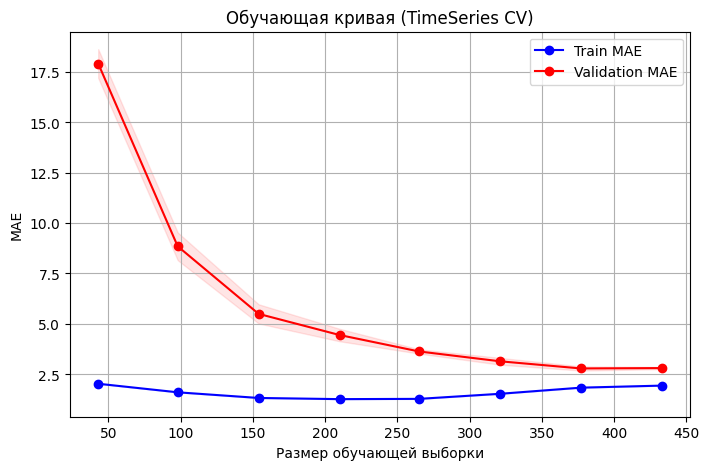

MAE: 2.5144
MAPE: 87.2552
WAPE: 0.2351
Directional_Accuracy: 0.5754
Directional_R2: -0.7836

======== RandomForestRegressor ========


====== 1 дней ====



Best trial: 16. Best value: 1.54145: 100%|██████████| 50/50 [00:41<00:00,  1.22it/s]


MAE: 1.5854
MAPE: 49.6540
WAPE: 0.1466
Directional_Accuracy: 0.6265
Directional_R2: 0.2180

====== 2 дней ====



Best trial: 23. Best value: 2.04978: 100%|██████████| 50/50 [00:24<00:00,  2.04it/s]


MAE: 1.9935
MAPE: 65.0272
WAPE: 0.1842
Directional_Accuracy: 0.5940
Directional_R2: -0.1991

====== 3 дней ====



...

Best trial: 39. Best value: 2.31273: 100%|██████████| 50/50 [00:32<00:00,  1.55it/s]


MAE: 2.1621
MAPE: 65.8236
WAPE: 0.1958
Directional_Accuracy: 0.6028
Directional_R2: -0.4356

====== 6 дней ====



Best trial: 14. Best value: 2.33249: 100%|██████████| 50/50 [00:29<00:00,  1.70it/s]


MAE: 2.1730
MAPE: 66.6298
WAPE: 0.1937
Directional_Accuracy: 0.5948
Directional_R2: -0.4506

====== 7 дней ====



Best trial: 11. Best value: 2.35371: 100%|██████████| 50/50 [00:25<00:00,  1.98it/s]


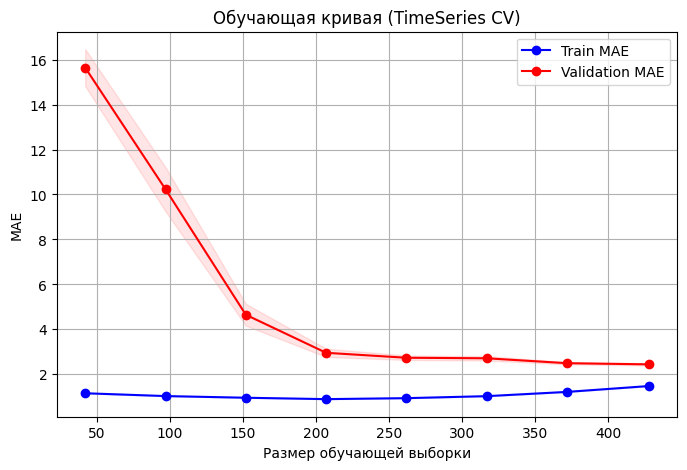

MAE: 2.1808
MAPE: 67.7772
WAPE: 0.1915
Directional_Accuracy: 0.5728
Directional_R2: -0.5085

======= GradientBoostingRegressor ========


====== 1 дней ====



Best trial: 42. Best value: 1.51266: 100%|██████████| 50/50 [01:10<00:00,  1.41s/it]


MAE: 1.4893
MAPE: 38.9326
WAPE: 0.1279
Directional_Accuracy: 0.6400
Directional_R2: 0.2530

====== 2 дней ====



Best trial: 44. Best value: 2.02204: 100%|██████████| 50/50 [00:44<00:00,  1.13it/s]


MAE: 1.9542
MAPE: 51.7540
WAPE: 0.1673
Directional_Accuracy: 0.5906
Directional_R2: -0.3032

====== 3 дней ====



...

Best trial: 33. Best value: 2.3298: 100%|██████████| 50/50 [00:37<00:00,  1.33it/s] 


MAE: 2.1420
MAPE: 54.2685
WAPE: 0.1790
Directional_Accuracy: 0.5957
Directional_R2: -0.5894

====== 6 дней ====



Best trial: 47. Best value: 2.3747: 100%|██████████| 50/50 [00:48<00:00,  1.04it/s] 


MAE: 2.1440
MAPE: 60.1035
WAPE: 0.1767
Directional_Accuracy: 0.5867
Directional_R2: -0.6122

====== 7 дней ====



Best trial: 32. Best value: 2.39452: 100%|██████████| 50/50 [00:39<00:00,  1.26it/s]


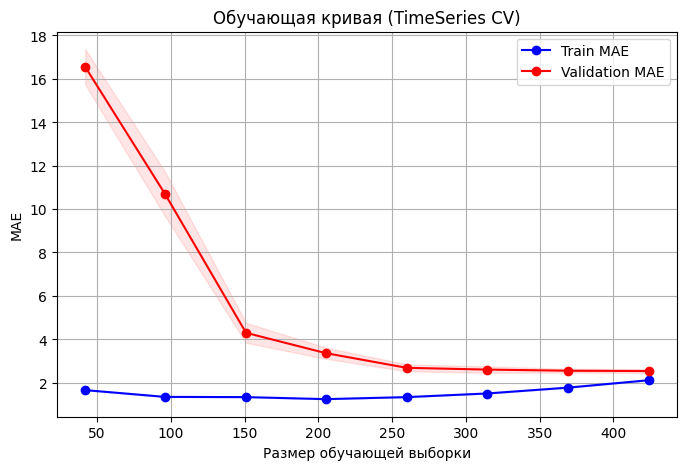

MAE: 2.0969
MAPE: 57.1115
WAPE: 0.1696
Directional_Accuracy: 0.5762
Directional_R2: -0.5080


In [30]:
print("\n----------- Direct models -----------------\n")
models_direct(df)

Здесь представлены метрики для простого обучения всех трех моделей по дням, а также график обучения за последний день, по графику можно видеть, что Train MAE не равна нулю, но и не зашкалиавет, значит модель нормально учится и не запоминает данные, также красная линия показывает, что изначально модель плохо предсказывает данные, но по мере обучения делает это все лучше и в конце синия и красная линя очень близки, что значит модель неплохо обучилась


----------- Reccursiv models -----------------


======== DecisionTreeRegressor ========



Best trial: 7. Best value: 2.7019: 100%|██████████| 50/50 [01:38<00:00,  1.96s/it]


Лучшие параметры: {'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 14}

====== 1 дней =====
MAE: 1.7854
MAPE: 82.8833
WAPE: 0.1616
Directional_Accuracy: 0.9633
Directional_R2: 0.9755

====== 2 дней =====
MAE: 2.3668
MAPE: 99.6692
WAPE: 0.2141
Directional_Accuracy: 0.9564
Directional_R2: 0.9607

====== 3 дней =====
MAE: 2.5378
MAPE: 131.4822
WAPE: 0.2290
Directional_Accuracy: 0.9495
Directional_R2: 0.9553

====== 4 дней =====
MAE: 2.5574
MAPE: 91.7008
WAPE: 0.2317
Directional_Accuracy: 0.9679
Directional_R2: 0.9547

====== 5 дней =====
MAE: 2.5965
MAPE: 106.6798
WAPE: 0.2369
Directional_Accuracy: 0.9518
Directional_R2: 0.9540

====== 6 дней =====
MAE: 2.8480
MAPE: 217.2603
WAPE: 0.2610
Directional_Accuracy: 0.9450
Directional_R2: 0.9481

====== 7 дней =====
MAE: 2.8259
MAPE: 106.9317
WAPE: 0.2583
Directional_Accuracy: 0.9404
Directional_R2: 0.9467


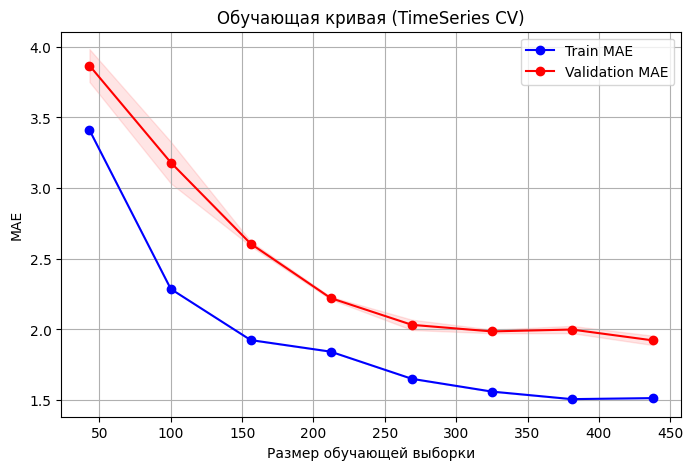

In [31]:
print("\n----------- Reccursiv models -----------------\n")
print("\n======== DecisionTreeRegressor ========\n")
model_reccursiv(df, "tree")

Здесь представлена модель рекурсивного обучения дерева, по мерикам все довольно неплохо. Также это подтверждает график, что изначально когда данных мало она плохо предскаазывате значания и на данных которые видит и на новых, но потом со временем предсказания становятся все лучше и в конце линии пости сошлись, но не равны нулю, это значит что модель обучилась более менее адекватно


======== RandomForestRegressor ========



Best trial: 25. Best value: 2.04385: 100%|██████████| 50/50 [00:26<00:00,  1.87it/s]


Лучшие параметры: {'n_estimators': 59, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt'}

====== 1 дней =====
MAE: 1.6249
MAPE: 82.2198
WAPE: 0.1470
Directional_Accuracy: 0.9656
Directional_R2: 0.9802

====== 2 дней =====
MAE: 1.9953
MAPE: 113.4719
WAPE: 0.1805
Directional_Accuracy: 0.9702
Directional_R2: 0.9710

====== 3 дней =====
MAE: 2.1079
MAPE: 112.4648
WAPE: 0.1902
Directional_Accuracy: 0.9587
Directional_R2: 0.9693

====== 4 дней =====
MAE: 2.1425
MAPE: 103.3867
WAPE: 0.1941
Directional_Accuracy: 0.9656
Directional_R2: 0.9678

====== 5 дней =====
MAE: 2.2148
MAPE: 88.2140
WAPE: 0.2021
Directional_Accuracy: 0.9610
Directional_R2: 0.9655

====== 6 дней =====
MAE: 2.4038
MAPE: 95.2692
WAPE: 0.2203
Directional_Accuracy: 0.9450
Directional_R2: 0.9598

====== 7 дней =====
MAE: 2.3550
MAPE: 81.6530
WAPE: 0.2153
Directional_Accuracy: 0.9610
Directional_R2: 0.9610


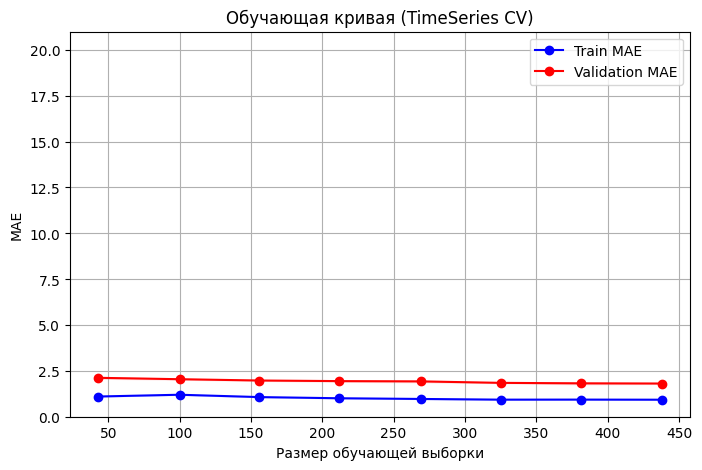

In [32]:
print("\n======== RandomForestRegressor ========\n")
model_reccursiv(df, "forest")

здесь тоже метрики довольно не плохо, и график тоже выглядет хорошо. Линии изначально идут близко и не внуле, это значит что модель изначально не плохо предсказывает результат.


======== GradientBoostingRegressor ========



Best trial: 6. Best value: 2.25183: 100%|██████████| 50/50 [06:23<00:00,  7.67s/it]


Лучшие параметры: {'n_estimators': 200, 'learning_rate': 0.021914163551309655, 'max_depth': 5, 'min_samples_split': 14, 'min_samples_leaf': 1, 'subsample': 0.8971018717459527, 'max_features': 'log2'}

====== 1 дней =====
MAE: 1.6156
MAPE: 80.9289
WAPE: 0.1462
Directional_Accuracy: 0.9633
Directional_R2: 0.9804

====== 2 дней =====
MAE: 2.0692
MAPE: 111.7712
WAPE: 0.1872
Directional_Accuracy: 0.9702
Directional_R2: 0.9705

====== 3 дней =====
MAE: 2.2062
MAPE: 97.7631
WAPE: 0.1991
Directional_Accuracy: 0.9610
Directional_R2: 0.9666

====== 4 дней =====
MAE: 2.2113
MAPE: 94.3551
WAPE: 0.2003
Directional_Accuracy: 0.9633
Directional_R2: 0.9664

====== 5 дней =====
MAE: 2.2047
MAPE: 85.3877
WAPE: 0.2011
Directional_Accuracy: 0.9587
Directional_R2: 0.9662

====== 6 дней =====
MAE: 2.4093
MAPE: 95.0445
WAPE: 0.2208
Directional_Accuracy: 0.9427
Directional_R2: 0.9605

====== 7 дней =====
MAE: 2.3774
MAPE: 84.9578
WAPE: 0.2173
Directional_Accuracy: 0.9495
Directional_R2: 0.9615


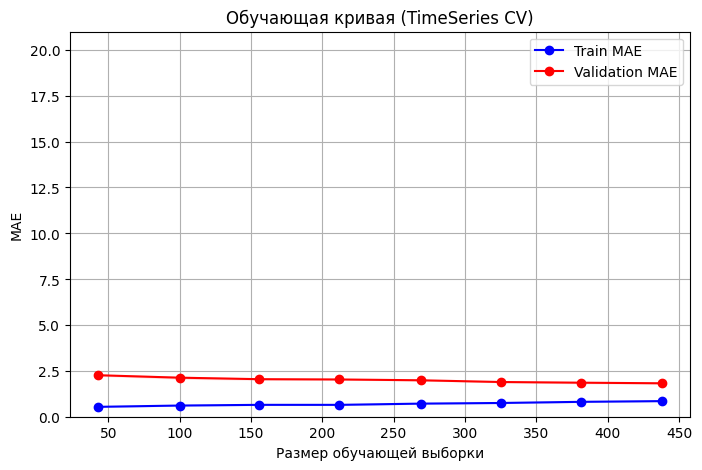

In [33]:
print("\n======== GradientBoostingRegressor ========\n")
model_reccursiv(df, "boost")

Здесь ситуация похожа на другие случаи обучения реккурсивно моделей, поэтому тут тоже все более менее хорошо